# Práctica: Regresión Logística (nuevo dataset)

En esta práctica vas a repetir lo aprendido con un conjunto de datos diferente.

Objetivos:
- implementar el modelo logístico;
- calcular entropía cruzada binaria;
- entrenar con gradiente descendente;
- graficar frontera de decisión;
- medir accuracy.

In [181]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(123)

## 1) Crear un nuevo dataset

Pistas:
- Define el total de muestras `N`.
- Crea `X0` y `X1` con `torch.randn` para dos clases.
- Usa centros distintos para cada clase sumando vectores (por ejemplo, un centro negativo y otro positivo).
- Une ambas clases en `X` con `torch.cat(..., dim=0)`.
- Crea etiquetas `y` con ceros y unos, también concatenadas.
- Imprime `X.shape` y `y.shape` para verificar dimensiones.

In [182]:
# TODO: define el total de muestras
N = 200

sigma = 1.1
# TODO: crea los datos de la clase 0
X0 = sigma * torch.randn(N//2, 2) + torch.tensor([2, 2])

# TODO: crea los datos de la clase 1
X1 = sigma * torch.randn(N//2, 2) + torch.tensor([-2, -2])

# TODO: concatena para formar X
X = torch.cat([X0, X1], dim=0)

# TODO: crea y concatena etiquetas para formar y
y = torch.cat([
    torch.zeros(N//2),
    torch.ones(N//2)
], dim=0)

# TODO: imprime las dimensiones
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([200, 2])
y shape: torch.Size([200])


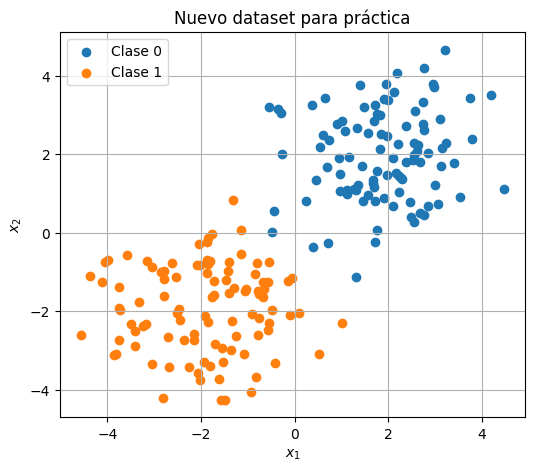

In [183]:
def plot_data(X, y):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title("Nuevo dataset para práctica")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_data(X, y)

## 2) Inicializar parámetros

Pistas:
- Debes crear tres parámetros: `phi_0`, `phi_1`, `phi_2`.
- Inicialízalos en cero.
- Cada uno debe ser entrenable (`requires_grad=True`).
- Imprime los valores iniciales para comprobar.

In [184]:
# TODO: crea parámetros entrenables
phi_0 = torch.tensor([0.0], requires_grad=True)
phi_1 = torch.tensor([0.0], requires_grad=True)
phi_2 = torch.tensor([0.0], requires_grad=True)

# TODO: imprime valores iniciales
print("phi_0 inicial", phi_0.item())
print("phi_1 inicial", phi_1.item())
print("phi_2 inicial", phi_2.item())

phi_0 inicial 0.0
phi_1 inicial 0.0
phi_2 inicial 0.0


## 3) Forward y pérdida

Pistas:
- $z = \phi_0 + \phi_1 x_1 + \phi_2 x_2$
- $\hat{y}=\sigma(z)$
- Usa `torch.sigmoid` para obtener `y_hat`.
- Usa `eps` para evitar `log(0)`.
- Calcula `loss` con entropía cruzada binaria promedio.
- Imprime la pérdida inicial con `.item()`.

In [185]:
eps = 1e-8

# TODO: calcula z
z = phi_0 + phi_1 * X[:,0] + phi_2 * X[:,1]

# TODO: calcula y_hat
y_hat = torch.sigmoid(z)

# TODO: calcula loss (entropía cruzada binaria)
loss = -torch.mean(y*torch.log(y_hat + eps)+(1 - y)*torch.log(1 - y_hat + eps))

# TODO: imprime pérdida inicial
print("Pérdida inicial:", loss.item())

Pérdida inicial: 0.6931471824645996


## 4) Entrenamiento

Pistas:
- Reinicia parámetros antes de entrenar.
- Define `eta`, `epochs` y `loss_history`.
- En cada época: forward, pérdida, backward, actualización y limpieza de gradientes.
- Guarda `loss.item()` en `loss_history`.
- Al final imprime parámetros y pérdida final.

In [186]:
# TODO: reinicia parámetros entrenables
phi_0 = torch.tensor([0.0], requires_grad=True)
phi_1 = torch.tensor([0.0], requires_grad=True)
phi_2 = torch.tensor([0.0], requires_grad=True)

# TODO: define hiperparámetros
eta = 0.1
epochs = 10000
loss_history = []

for epoch in range(epochs):
    # TODO: forward
    z = phi_0 + phi_1 * X[:, 0] + phi_2 * X[:,1]
    y_hat = torch.sigmoid(z)

    # TODO: pérdida
    eps = 1e-8
    loss = -torch.mean(y*torch.log(y_hat + eps) + (1-y)*torch.log(1-y_hat+eps))

    # TODO: backward
    loss.backward()

    # TODO: actualización
    with torch.no_grad():
        phi_0 -= eta * phi_0.grad
        phi_1 -= eta * phi_1.grad
        phi_2 -= eta * phi_2.grad

    # TODO: limpiar gradientes
    phi_0.grad.zero_()
    phi_1.grad.zero_()
    phi_2.grad.zero_()

    # TODO: guarda la pérdida
    loss_history.append(loss.item())

# TODO: imprime parámetros finales y pérdida final
print("phi_0: ", phi_0.item())
print("phi_1: ", phi_1.item())
print("phi_2: ", phi_2.item())
print("loss: ", loss.item())

phi_0:  -1.7980599403381348
phi_1:  -4.208635330200195
phi_2:  -3.57527756690979
loss:  0.009258562698960304


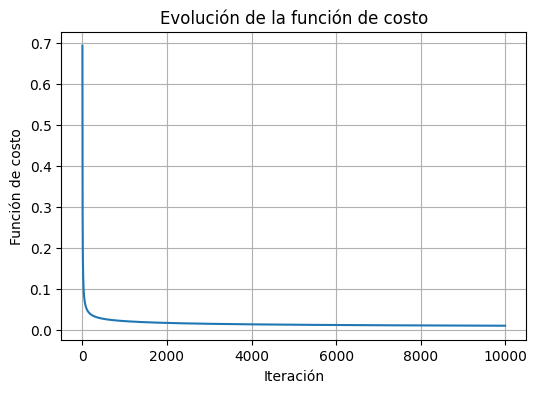

In [187]:
# TODO: grafica la evolución de la pérdida usando loss_history
# Pista: usa plt.figure, plt.plot, labels, grid y show
def plot_loss(loss_history):
    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteración")
    plt.ylabel("Función de costo")
    plt.title("Evolución de la función de costo")
    plt.grid(True)
    plt.show()

plot_loss(loss_history)

## 5) Frontera de decisión

Pistas:
- Grafica primero los puntos de las dos clases.
- Construye un rango de valores para `x1_vals`.
- Usa la ecuación de la frontera: $x_2 = -(\phi_0 + \phi_1 x_1) / \phi_2$.
- Dibuja la línea sobre el scatter.
- Agrega título, ejes, leyenda y cuadrícula.

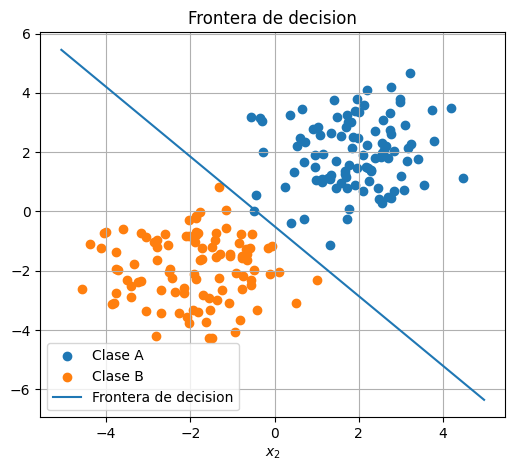

In [188]:
# TODO: crea la figura y grafica ambas clases
plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], label="Clase A")
plt.scatter(X[y==1, 0], X[y==1, 1], label="Clase B")

# TODO: define x1_vals en el rango de X[:, 0]
x1_vals = torch.linspace(X[:, 0].min() - 0.5, X[:,0].max() + 0.5, 1000)

# TODO: calcula x2_vals con la fórmula de frontera
with torch.no_grad():
    x2_vals = - (phi_0  + phi_1 * x1_vals)/phi_2

# TODO: dibuja la frontera y agrega formato al gráfico
plt.plot(x1_vals.numpy(), x2_vals.numpy(), label="Frontera de decision")

plt.xlabel(r"$x_1$")
plt.xlabel(r"$x_2$")
plt.title("Frontera de decision")
plt.grid(True)
plt.legend()
plt.show()

## 6) Accuracy

Pistas:
- Calcula `z` y `y_hat` con los parámetros entrenados.
- Convierte probabilidades a etiquetas con umbral 0.5.
- Compara `y_pred` con `y` para obtener aciertos.
- Saca el promedio para obtener accuracy.
- Imprime el valor final.

In [189]:
# TODO: calcula probabilidades finales
z = phi_0 + phi_1 * X[:,0] + phi_2*X[:,1]
y_hat = torch.sigmoid(z)

# TODO: convierte probabilidades en etiquetas
y_pred = (y>=0.5).float()

# TODO: calcula accuracy
accuracy = (y_pred == y).float().mean()

# TODO: imprime accuracy
print("Accuracy: ", accuracy.item())

Accuracy:  1.0


## Extra (opcional)

Prueba y compara:
1. Cambiar `eta` a 0.01 y 0.2.
2. Cambiar `epochs` a 100 y 600.
3. Cambiar los centros de las clases para que se mezclen más.
4. ¿Qué pasa con la loss y el accuracy?